In [1]:
import awkward as ak

## Comparing MC scaling between JZ2 and JZ4

Ignoring JZ3 for now - though it needs to be rescalled as well - just because JZ2 should have a very large rescalling factor, and JZ4 should comparatively be lower.

Equation for the rescaling is:

$$v_i = \frac{w_i}{N} \left( \epsilon \cdot L \cdot \sigma \right)$$

Where the variables are defined as 
- $w_i$, original un-normalized MC event weight
- $N$, the normalization of the sample (for JZ slices, this is the sum of all un-normalized MC event weights)
- $\sigma$, the inclusive cross-section of the simulated process
- $L_i$, the integrated luminosity of the dataset campaign (e.g. 26 $fb^{-1}$ for MC23a)
- $\epsilon$, the selection efficiency of event filter(s) applied during the event generation chain

These values can be found using AMI. The definition of normalization taken from the [jetetmiss group documentations](https://atlas-jetetmiss.docs.cern.ch/users/QCD-samples/)

In [2]:
dfjz2 = ak.from_parquet("../jz2_000.parquet")
dfjz3 = ak.concatenate([ak.from_parquet("../jz3_training_000.parquet"), ak.from_parquet("../jz3_training_001.parquet")])

In [3]:
dfjz4 = ak.concatenate([
    ak.from_parquet("/data/agolub/bulk_processed_files/cr/mc23_13p6TeV.801169.Py8EG_A14NNPDF23LO_jj_JZ4.deriv.DAOD_LLP1.e8514_s4159_r15224_p7077_000.parquet"),
    ak.from_parquet("/data/agolub/bulk_processed_files/cr/mc23_13p6TeV.801169.Py8EG_A14NNPDF23LO_jj_JZ4.deriv.DAOD_LLP1.e8514_s4159_r15224_p7077_001.parquet"),
    ak.from_parquet("/data/agolub/bulk_processed_files/cr/mc23_13p6TeV.801169.Py8EG_A14NNPDF23LO_jj_JZ4.deriv.DAOD_LLP1.e8514_s4159_r15224_p7077_002.parquet"),
    ak.from_parquet("/data/agolub/bulk_processed_files/cr/mc23_13p6TeV.801169.Py8EG_A14NNPDF23LO_jj_JZ4.deriv.DAOD_LLP1.e8514_s4159_r15224_p7077_003.parquet")
])

In [ ]:
# dfjz4 = ak.from_parquet("/data/agolub/bulk_processed_files/cr/jz4_000_009.parquet")

## Calculating Scale Factor

Using code provided by Miles Cochran-Branson


In [4]:
import os
_DEFAULT_PMG_PATH = "../PMGxsecDB_mc23.txt"

_pmg_cache: dict[str, dict[int, tuple[float, float, float]]] = {}


def _load_pmg_db(pmg_xsec_db: str) -> dict[int, tuple[float, float, float]]:
    """Parse the PMG text file once and cache by path."""

    if pmg_xsec_db not in _pmg_cache:
        db = {}
        with open(pmg_xsec_db) as f:
            raw_header = f.readline().strip()
            col_names = [col.split("/")[0] for col in raw_header.split(":")]
            for line in f:
                fields = line.split()
                if not fields:
                    continue
                row = dict(zip(col_names, fields))
                db[int(row["dataset_number"])] = (
                    float(row["crossSection_pb"]),
                    float(row["kFactor"]),
                    float(row["genFiltEff"]),
                )
        _pmg_cache[pmg_xsec_db] = db
    return _pmg_cache[pmg_xsec_db]


def get_cross_section(
    dsid: int,
    additional_branching_ratio: float | None = None,
    additional_kfactor: float | None = None,
    pmg_xsec_db: str = _DEFAULT_PMG_PATH,
) -> float:
    """Return crossSection_pb * kFactor * genFiltEff [* additional_branching_ratio]."""

    db = _load_pmg_db(pmg_xsec_db)
    if dsid not in db:
        raise ValueError(f"DSID {dsid} not found in {pmg_xsec_db}")
    xsec, kfactor, filteff = db[dsid]
    result = xsec * kfactor * filteff
    if additional_branching_ratio is not None:
        result *= additional_branching_ratio
    if additional_kfactor is not None:
        result += additional_kfactor
    return result


In [58]:
jz2_cs = get_cross_section(801167)
jz3_cs = get_cross_section(801168)
jz4_cs = get_cross_section(801169)

In [73]:
scale_jz2 = jz2_cs * sum(dfjz2.mcEventWeight)
scale_jz3 = jz3_cs * sum(dfjz3.mcEventWeight)
scale_jz4 = jz4_cs * sum(dfjz4.mcEventWeight)

In [81]:
print(scale_jz2)
print(scale_jz3)
print(scale_jz4)

903074.25
71977.78
1556.871


In [74]:
# N = sum(dfjz2.mcEventWeight)
# sigma = 2.58E12 # fb
# lumi = 52.4 # fb^-1
# eps = 0.01006532 # unit-less
# scale_jz2 = sigma * eps * lumi / N
# print(f'{scale_jz2:e}')

In [75]:
# N = sum(dfjz3.mcEventWeight)
# sigma = 2.85E10 # fb
# eps = 0.01190834


Scaling factor for JZ4

In [76]:
# N = sum(dfjz4.mcEventWeight)
# sigma = 2.8E8 # fb
# lumi = 52.4 # fb^-1
# eps = 0.01374964 # unit-less
# scale_jz4 = sigma * lumi * eps / N
# print(scale_jz4)

Now have to multiply the mcEventWeight column by the corresponding scale factors, and then use that as the weight when plotting

In [77]:
jz2_weights = dfjz2.mcEventWeight * scale_jz2
jz3_weights = dfjz3.mcEventWeight * scale_jz3
jz4_weights = dfjz4.mcEventWeight * scale_jz4

In [78]:
import matplotlib.pyplot as plt

In [79]:
# Combining datasets and weights to plot them
comb_ds = ak.concatenate([dfjz2, dfjz3, dfjz4])
comb_weights = ak.concatenate([jz2_weights, jz3_weights, jz4_weights])

Plotting weights to see what the distribution of the new weights and the old mcEventWeights look like

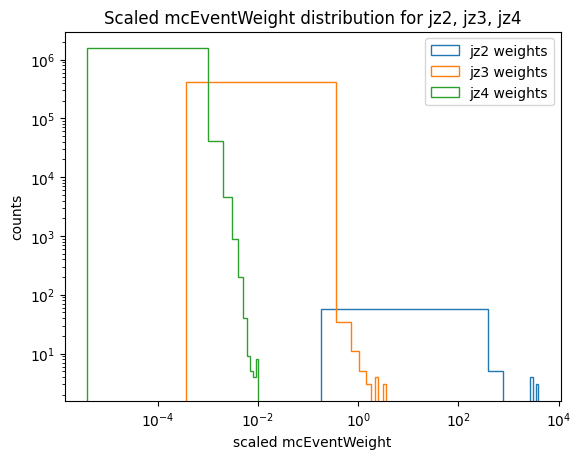

In [80]:
plt.hist(jz2_weights, histtype='step', bins=10, label="jz2 weights")
plt.hist(jz3_weights, histtype='step', bins=10, label="jz3 weights")
plt.hist(jz4_weights, histtype='step', bins=10, label="jz4 weights")
plt.xlabel("scaled mcEventWeight")
plt.ylabel("counts")
plt.xscale("log")
plt.yscale("log")
plt.legend()
plt.title("Scaled mcEventWeight distribution for jz2, jz3, jz4")
plt.show()

Compared to the mcEventWeight values that we had for the old cr samples, these are very small (except for a few of the jz2 jets, which are quite large). What if we plot just the unscaled mcEventWeight values?

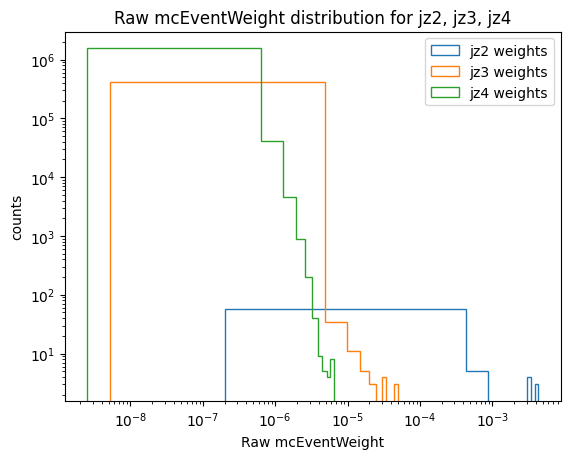

In [63]:
plt.hist(dfjz2.mcEventWeight, histtype='step', bins=10, label="jz2 weights")
plt.hist(dfjz3.mcEventWeight, histtype='step', bins=10, label="jz3 weights")
plt.hist(dfjz4.mcEventWeight, histtype='step', bins=10, label="jz4 weights")
plt.xlabel("Raw mcEventWeight")
plt.ylabel("counts")
plt.xscale("log")
plt.yscale("log")
plt.legend()
plt.title("Raw mcEventWeight distribution for jz2, jz3, jz4")
plt.show()

okay...these look worse. Scaling increases the weight, but something isn't going right in the scaling. Recheck variables inputted into the rescaling? ... that said it won't change the distribution, just will change the scale of it. Will have to rescale mc to data anyway by the end. So it won't matter really if we're scaled wrong by an integer, matters more about the distribution (so only things that are different per JZ slice)

Maybe the luminosity should be added in. It is, frankly, unclear to me if/when the luminosity should be added 

lumi for mc23: 25204.3

In [64]:
lumi = 25204.3

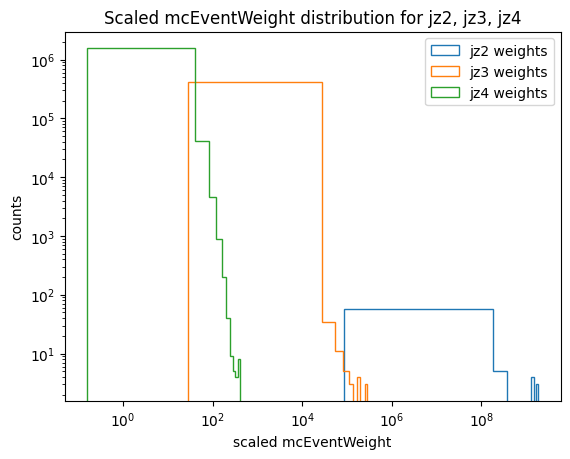

In [65]:
plt.hist(jz2_weights*lumi, histtype='step', bins=10, label="jz2 weights")
plt.hist(jz3_weights*lumi, histtype='step', bins=10, label="jz3 weights")
plt.hist(jz4_weights*lumi, histtype='step', bins=10, label="jz4 weights")
plt.xlabel("scaled mcEventWeight")
plt.ylabel("counts")
plt.xscale("log")
plt.yscale("log")
plt.legend()
plt.title("Scaled mcEventWeight distribution for jz2, jz3, jz4")
plt.show()

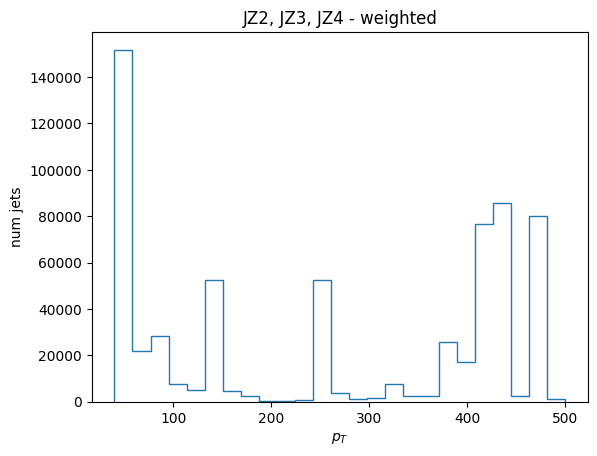

In [66]:
plt.hist(comb_ds.pt, histtype='step', weights=comb_weights, bins=25)
plt.xlabel("$p_T$")
plt.ylabel("num jets")
plt.title("JZ2, JZ3, JZ4 - weighted")
plt.show()

In [67]:
data_ds = ak.from_parquet("../crdata_test_000.parquet")

In [68]:
len(data_ds.pt)

248703

In [69]:
# resizing the combined dataset to be the same length as the data dataset
# NOTE this removes jz4 samples entirely
smallercombds = comb_ds[:len(data_ds)]
smallerweights = comb_weights[:len(data_ds)]

In [70]:
rescaled_smallerweights = smallerweights * (len(data_ds)/sum(smallerweights))

In [71]:
rescaled_mcweight = smallercombds.mcEventWeight * (len(data_ds)/sum(smallercombds.mcEventWeight))

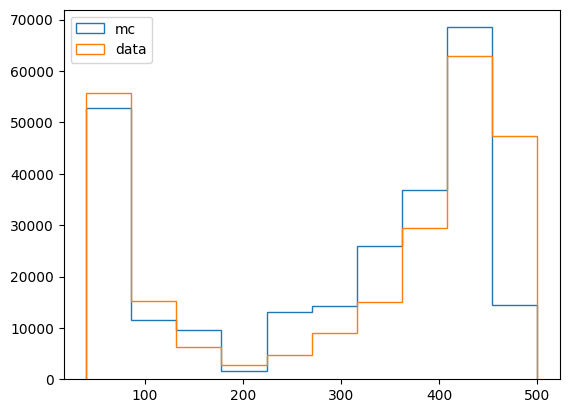

In [72]:
plt.hist(smallercombds.pt, weights=rescaled_mcweight, histtype="step", label="mc")
plt.hist(data_ds.pt, histtype="step", label="data")
plt.legend()
plt.show()

In [54]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

def plot_ratio(mc_vals, data_vals, mc_weights, bins=25,
               mc_label="MC", data_label="Data",
               title="", xlabel="$p_T$"):
    mc_vals    = np.asarray(mc_vals)
    data_vals  = np.asarray(data_vals)
    mc_weights = np.asarray(mc_weights)

    bin_range = (min(mc_vals.min(), data_vals.min()),
                 max(mc_vals.max(), data_vals.max()))

    mc_counts,   bin_edges = np.histogram(mc_vals,   bins=bins, range=bin_range, weights=mc_weights)
    mc_var,      _         = np.histogram(mc_vals,   bins=bin_edges, weights=mc_weights**2)
    data_counts, _         = np.histogram(data_vals, bins=bin_edges)

    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

    with np.errstate(divide='ignore', invalid='ignore'):
        ratio     = np.where(mc_counts > 0, data_counts / mc_counts, np.nan)
        ratio_err = np.where(mc_counts > 0, np.sqrt(data_counts) / mc_counts, np.nan)

    fig = plt.figure(figsize=(8, 6))
    gs  = gridspec.GridSpec(2, 1, height_ratios=[3, 1], hspace=0.05)
    ax_top = fig.add_subplot(gs[0])
    ax_bot = fig.add_subplot(gs[1], sharex=ax_top)

    ax_top.hist(bin_edges[:-1], bin_edges, weights=mc_counts,   histtype='step', label=mc_label)
    ax_top.hist(bin_edges[:-1], bin_edges, weights=data_counts, histtype='step', label=data_label)
    ax_top.legend()
    ax_top.set_ylabel("num jets")
    ax_top.set_title(title)
    plt.setp(ax_top.get_xticklabels(), visible=False)

    ax_bot.axhline(1.0, color='gray', linestyle='--', linewidth=0.8)
    ax_bot.errorbar(bin_centers, ratio, yerr=ratio_err, fmt='k.', markersize=4)
    ax_bot.set_xlabel(xlabel)
    ax_bot.set_ylabel("Data / MC")
    ax_bot.set_ylim(0.0, 2.0)

    plt.show()

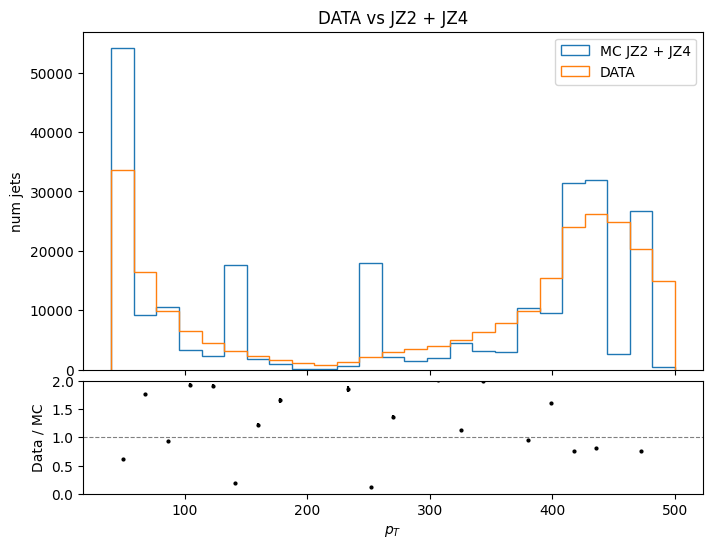

In [55]:
plot_ratio(
    smallercombds.pt, data_ds.pt, rescaled_smallerweights,
    mc_label="MC JZ2 + JZ4", data_label="DATA",
    title="DATA vs JZ2 + JZ4",
)

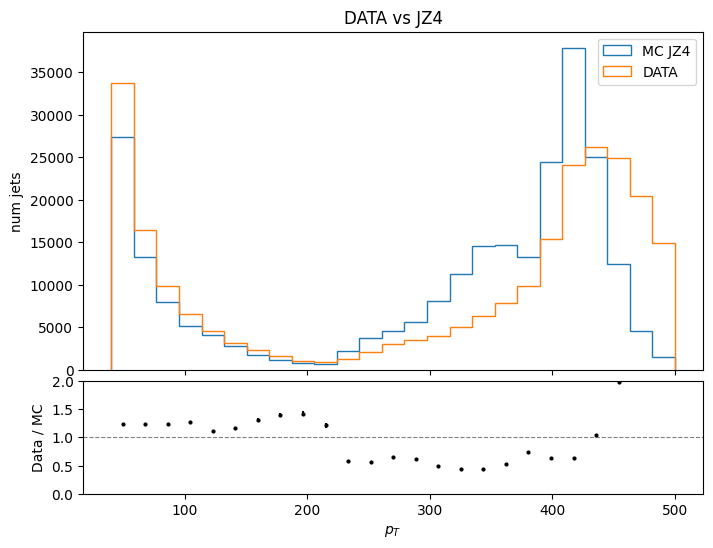

In [56]:
plot_ratio(
    comb_ds[:248703].pt, data_ds.pt, np.ones(248703),
    mc_label="MC JZ4", data_label="DATA",
    title="DATA vs JZ4",
)

## Decoding where the jets are from in JZ2

The JZ2 jets contain only 70 jets after they go through the cuts. We would expect basically 0 to make it through a J400 trigger. We are trying to figure out what is causing the jets to actually make it through the cut

In [15]:
jz2_with_truth = ak.from_parquet("../jz2_000.parquet")

In [16]:
len(jz2_with_truth)

70

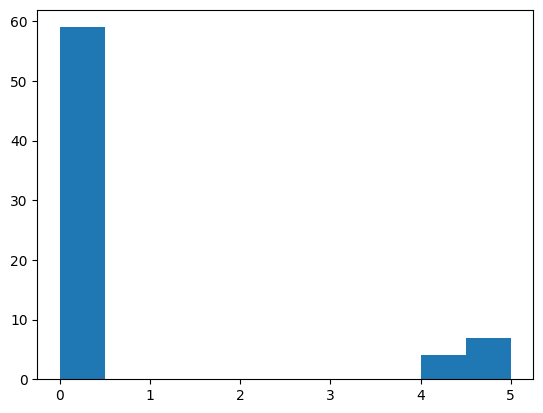

In [19]:
plt.hist(jz2_with_truth.jet_truthLabelID)
plt.show()